In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyinterpolate import (
    build_experimental_variogram,
    build_theoretical_variogram,
    ordinary_kriging
)
from pyinterpolate.kriging.point.ordinary import experimental_ordinary_kriging_lsa

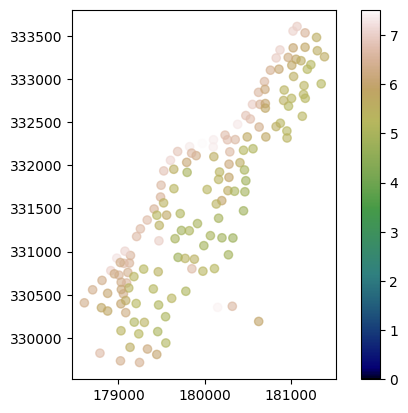

In [6]:
# Load elements data

# Variogram parameters
STEP_SIZE = 100
MAX_RANGE = 1600
ALLOWED_MODELS = 'safe'

df = pd.read_csv(
    'meuse.csv', usecols=['x', 'y', 'zinc']
)
# Populate geometry column and set CRS

zinc_geometry = gpd.points_from_xy(x=df['x'], y=df['y'], crs='epsg:2180')
gdf = gpd.GeoDataFrame(df, geometry=zinc_geometry)
gdf['z'] = np.log(gdf['zinc'] + 1)

# Transform crs to metric values
gdf.plot(column='z', cmap='gist_earth', alpha=0.6, vmin=0, legend=True);

In [10]:
step_size = 100  # meters
max_range = 2000  # meters

In [11]:
from tqdm import tqdm
from time import perf_counter


neighbors_number = [4, 8, 16, 32, 64]
number_of_trials = 100

outputs = []

for _ in range(number_of_trials):
    for nn in tqdm(neighbors_number):
        # Divide dataset into train and test set
        train = gdf.sample(n=int(0.1*len(gdf)))
        test = gdf.loc[~gdf.index.isin(train.index)]

        # Take sample from test, we don't need a whole dataset
        test_sample = test.sample(n=100)

        # Fit semivariogram model
        exp_var = build_experimental_variogram(
            values=train['z'],
            geometries=train['geometry'],
            step_size=step_size,
            max_range=max_range
        )
        theo_var = build_theoretical_variogram(
            experimental_variogram=exp_var,
            models_group='linear'
        )

        # Predict new values
        ty0 = perf_counter()
        yhats = ordinary_kriging(
            theoretical_model=theo_var,
            known_values=train['z'],
            known_geometries=train['geometry'],
            unknown_locations=test_sample['geometry'],
            no_neighbors=nn,
            use_all_neighbors_in_range=False,
            progress_bar=False
        )
        ty = perf_counter() - ty0

        yhats = yhats[:, 0]
        avg_rmse = np.sqrt(np.mean((test_sample['z'] - yhats)**2))

        # Predict using lsa
        ty_lsa0 = perf_counter()
        yhats_lsa = experimental_ordinary_kriging_lsa(
            theoretical_model=theo_var,
            known_values=train['z'],
            known_geometries=train['geometry'],
            unknown_locations=test_sample['geometry'],
            no_neighbors=nn,
            use_all_neighbors_in_range=False,
            progress_bar=False
        )
        ty_lsa = perf_counter() - ty_lsa0

        yhats_lsa = yhats_lsa[:, 0]

        avg_rmse_lsa = np.sqrt(np.mean((test_sample['z'] - yhats_lsa)**2))

        outputs.append([avg_rmse, ty, avg_rmse_lsa, ty_lsa, nn])

100%|██████████| 5/5 [00:00<00:00,  5.87it/s]


In [12]:
diffdf = pd.DataFrame(data=outputs, columns=['rmse', 'time-linalgsolve', 'rmse_lsa', 'time-lsa', 'nn'])

In [13]:
diffdf.groupby(['nn']).mean()

,rmse,time-linalgsolve,rmse_lsa,time-lsa
nn,,,,
4,0.686030,0.016851,0.686030,0.022247
8,0.670949,0.017058,0.670949,0.023311
16,0.658241,0.017494,0.658241,0.025521
32,0.667449,0.017480,0.667449,0.025632
64,0.656718,0.017562,0.656718,0.025543


In [14]:
diffdf['dataset'] = 'meuse'

In [15]:
diffdf.to_csv('lsa-comp-meuse.csv')